<a href="https://colab.research.google.com/github/deepan98raj-dotcom/Assessment/blob/main/Machine_Learning_Algorithms_Assign_on_06_08_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

       alcohol  malic_acid       ash   magnesium      proline  target
0    12.498160    3.974361  1.495935   85.204156  1269.548565       2
1    14.802857    1.129114  3.014851   95.073131   491.859738       1
2    13.927976    1.524306  2.259980   85.930944  1085.956281       2
3    13.394634    5.282626  2.870269   77.983228  1128.614495       2
4    11.624075    3.792788  1.908094   80.857228   872.631201       0
..         ...         ...       ...         ...          ...     ...
195  12.396838    5.446862  2.200527  148.491152   406.398067       0
196  13.903823    5.077905  2.568360  153.890645  1564.073633       2
197  14.588441    2.887870  1.627408  120.861987   469.819721       0
198  14.548346    4.529442  1.665349  132.698574  1610.232770       0
199  14.119502    4.548169  1.377650  153.024944   903.300094       2

[200 rows x 6 columns]
     alcohol  malic_acid       ash  magnesium      proline  target
0  12.498160    3.974361  1.495935  85.204156  1269.548565       2
1 

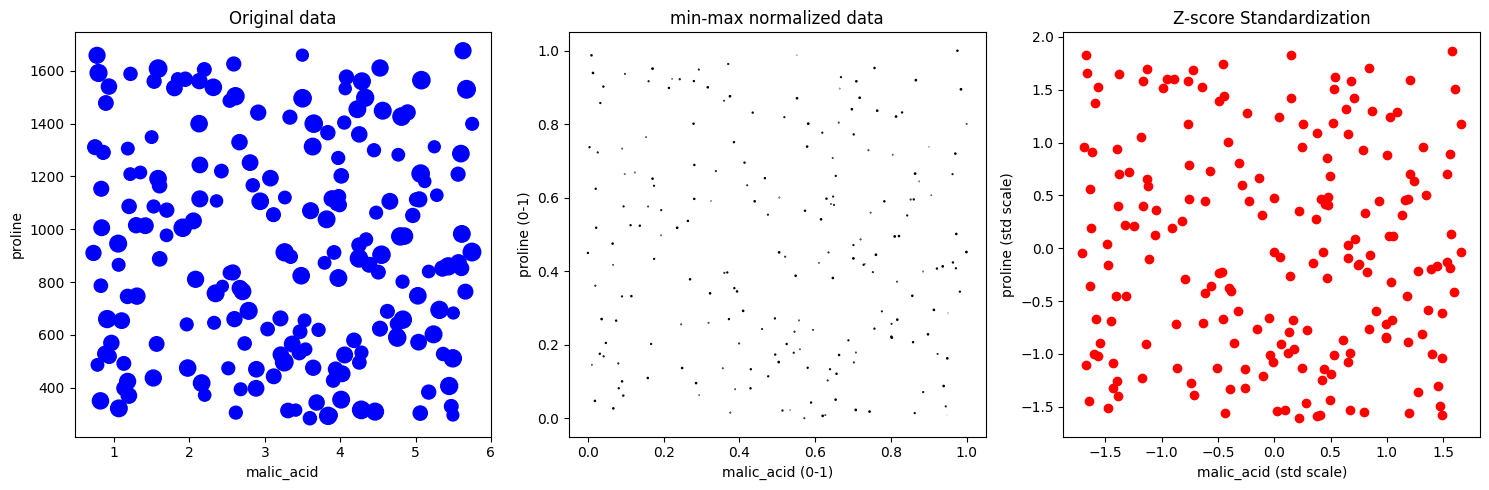

In [ ]:
#Normalization_Wine

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/1_Normalization_Wine.csv')

print(df)
print(df.head())
print(df.shape)

print('___'*35)


df_norm = df.copy()
for col in ['malic_acid','proline','magnesium','ash']:
    min_val = df[col].min()
    max_val = df[col].max()
    df_norm[col] = (df[col] - min_val) / (max_val - min_val)
print('\nNormalized Dataset:\n', df_norm)

#__________________Z-score Standardization______________________

df_zscore = df.copy()
for col in [ 'malic_acid','proline','magnesium','ash']:
    mean_val = df[col].mean()
    std_val = df[col].std()
    df_zscore[col] = (df[col] - mean_val)/std_val
print('\nZ-score standardized Dataset:\n', df_zscore)

#_________________________plot comparison______________________________

fig, axes = plt.subplots(1,3,figsize=(15,5))

#Original
axes[0].scatter(df['malic_acid'],df['proline'],s=df['magnesium'],color='blue')
axes[0].set_title('Original data')
axes[0].set_xlabel('malic_acid')
axes[0].set_ylabel('proline')

#Min-Max Normalization
axes[1].scatter(df_norm['malic_acid'],df_norm['proline'],s=df_norm['magnesium'],color='black')
axes[1].set_title('min-max normalized data')
axes[1].set_xlabel('malic_acid (0-1)')
axes[1].set_ylabel('proline (0-1)')

#Zscore
axes[2].scatter(df_zscore['malic_acid'],df_zscore['proline'],color='red')
axes[2].set_title('Z-score Standardization')
axes[2].set_xlabel('malic_acid (std scale)')
axes[2].set_ylabel('proline (std scale)')

plt.tight_layout()
plt.show()

     survived  pclass     sex   age    fare
0           0       1  female  16.9    1.37
1           0       3  female  43.3  110.64
2           0       3    male   8.6   51.30
3           0       2    male  36.6   11.09
4           1       3    male  60.7  125.14
..        ...     ...     ...   ...     ...
195         0       3    male  10.6   26.28
196         1       2    male  49.6   88.38
197         0       1    male  62.2    1.72
198         1       2    male  51.9   17.36
199         0       2    male  42.9    9.64

[200 rows x 5 columns]
   survived  pclass     sex   age    fare
0         0       1  female  16.9    1.37
1         0       3  female  43.3  110.64
2         0       3    male   8.6   51.30
3         0       2    male  36.6   11.09
4         1       3    male  60.7  125.14
(200, 5)
_________________________________________________________________________________________________________
     survived  pclass     sex   age    fare  Age_high
0           0       1  fema

/tmp/ipykernel_1950/1482400775.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Age_high'], ax=axes_bin[1], palette='pastel')


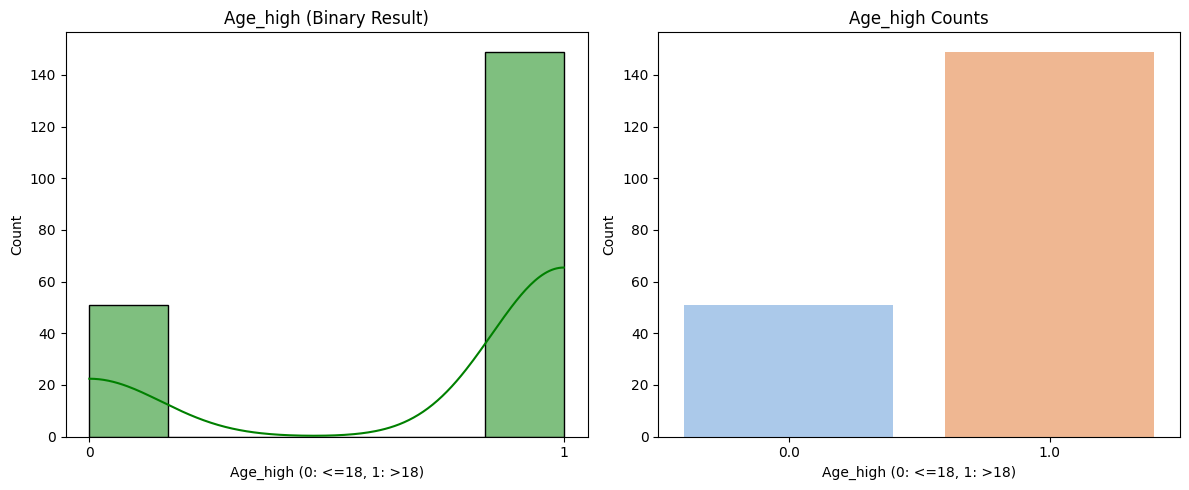

In [ ]:
#Binarization_Titanic

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import Binarizer

df = pd.read_csv('/content/2_Binarization_Titanic.csv')

print(df)
print(df.head())
print(df.shape)

print('___'*35)

binarizer_age = Binarizer(threshold=18)
df['Age_high'] = binarizer_age.fit_transform(df[['age']])
print(df)

### _______________________ visualization _____________________________

# Create a new figure and axes for the binarization plots
fig_bin, axes_bin = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Histogram of binarized Age_high
sns.histplot(df['Age_high'], bins=6, kde=True, ax=axes_bin[0], color='green')
axes_bin[0].set_title('Age_high (Binary Result)')
axes_bin[0].set_xticks([0, 1]) # Set x-ticks to clearly show 0 and 1
axes_bin[0].set_xlabel('Age_high (0: <=18, 1: >18)')
axes_bin[0].set_ylabel('Count')

# Plot 2: Countplot of binarized Age_high
sns.countplot(x=df['Age_high'], ax=axes_bin[1], palette='pastel')
axes_bin[1].set_title('Age_high Counts')
axes_bin[1].set_xlabel('Age_high (0: <=18, 1: >18)')
axes_bin[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

     total_bill   tip     sex smoker   day    time
0         37.89  3.71    Male     No  Thur   Lunch
1         49.16  6.39    Male     No  Thur   Lunch
2         16.54  3.68  Female    Yes   Fri   Lunch
3         34.44  3.70  Female     No   Sat  Dinner
4         13.91  7.69    Male    Yes   Fri  Dinner
..          ...   ...     ...    ...   ...     ...
195       29.33  1.21  Female     No  Thur  Dinner
196        9.34  7.81  Female     No   Fri  Dinner
197       15.89  5.13    Male     No   Sat   Lunch
198        5.56  3.60  Female     No   Sun  Dinner
199       26.09  9.10    Male    Yes   Sun  Dinner

[200 rows x 6 columns]
   total_bill   tip     sex smoker   day    time
0       37.89  3.71    Male     No  Thur   Lunch
1       49.16  6.39    Male     No  Thur   Lunch
2       16.54  3.68  Female    Yes   Fri   Lunch
3       34.44  3.70  Female     No   Sat  Dinner
4       13.91  7.69    Male    Yes   Fri  Dinner
(200, 6)
_____________________________________________________________

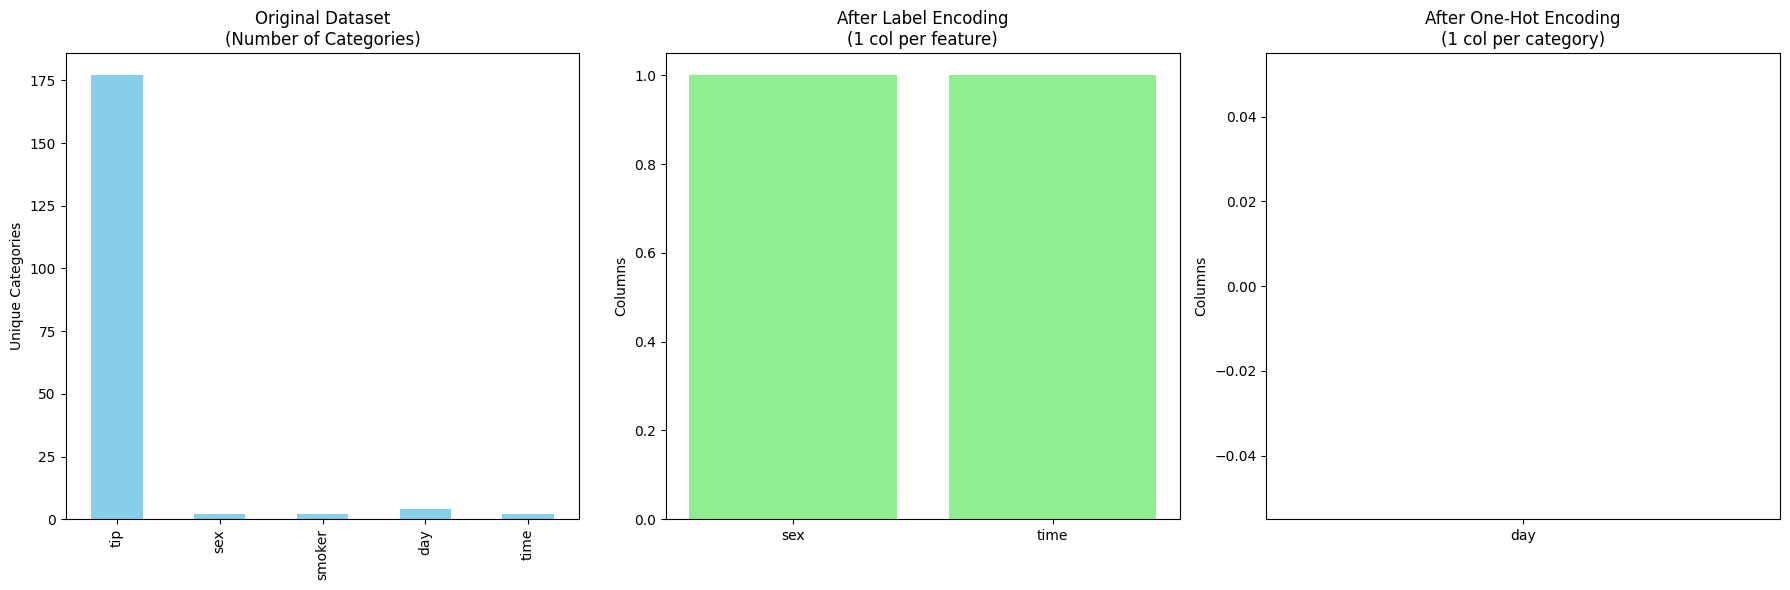

In [ ]:
#Label Encoding And One-hot Encoding
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder\

df = pd.read_csv('/content/3_Encoding_Tips.csv')

print(df)
print(df.head())
print(df.shape)

print('___'*35)

# # ________________Label Encoding____________________
label_encoder = LabelEncoder()

df_label = df.copy()
df_label['sex'] = label_encoder.fit_transform(df['sex'])
df_label['time'] = label_encoder.fit_transform(df['time'])

print("\n Label Encoded Dataset")
print(df_label)

#__________________One Hot Encoding______________________
df_onehot = pd.get_dummies(df, columns=['day'])

print("\n One-Hot Encoded Dataset")
print(df_onehot)


#________________Visualization___________________________
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original data
df[['tip','sex','smoker','day','time']].nunique().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title("Original Dataset\n(Number of Categories)")
axes[0].set_ylabel("Unique Categories")

# Label Encoded (sex and time)
axes[1].bar(['sex', 'time'], [1, 1], color='lightgreen')
axes[1].set_title("After Label Encoding\n(1 col per feature)")
axes[1].set_ylabel("Columns")

# One-Hot Encoded (day)
df_onehot_cols = [col for col in df_onehot.columns if col.startswith(('Genre_', 'Language_', 'Rating_'))]
feature_counts = {'day': sum(col.startswith('day_') for col in df_onehot_cols),}
axes[2].bar(feature_counts.keys(), feature_counts.values(), color='lightcoral')
axes[2].set_title("After One-Hot Encoding\n(1 col per category)")
axes[2].set_ylabel("Columns")

plt.tight_layout()
plt.show()


     survived  pclass     sex   age embarked
0           0       2  female  64.7        C
1           1       3    male  78.8        C
2           0       2    male  60.6        C
3           0       3  female  32.1        S
4           0       1  female  47.7        C
..        ...     ...     ...   ...      ...
195         1       2  female   NaN        S
196         0       2    male   NaN        S
197         1       1  female  37.3        S
198         1       1  female   NaN        S
199         0       2  female   NaN        Q

[200 rows x 5 columns]
   survived  pclass     sex   age embarked
0         0       2  female  64.7        C
1         1       3    male  78.8        C
2         0       2    male  60.6        C
3         0       3  female  32.1        S
4         0       1  female  47.7        C
(200, 5)
_________________________________________________________________________________________________________

 Dataset After Imputation
     survived  pclass     sex       

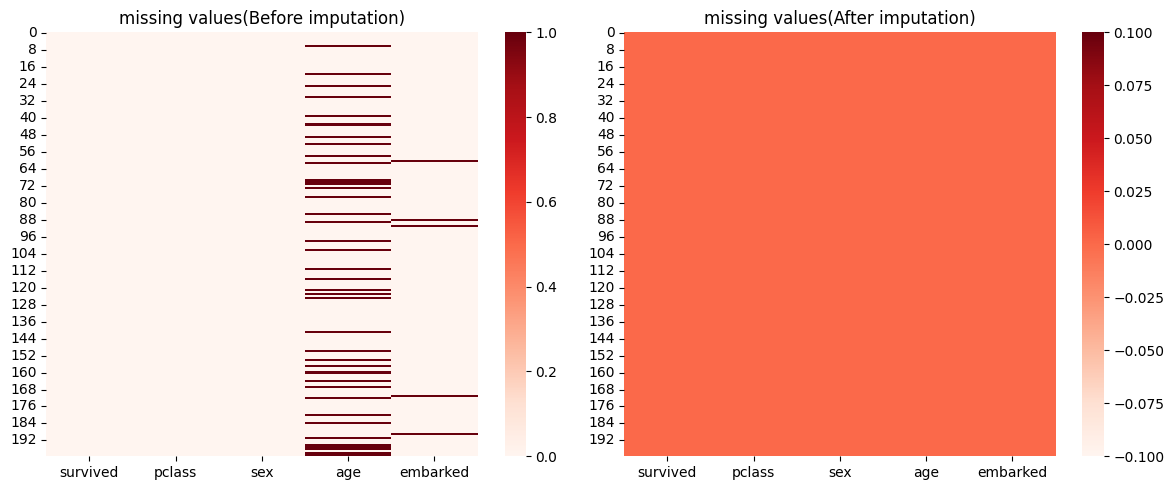

In [ ]:
# Imputation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer # Added this line

df = pd.read_csv('/content/4_Imputation_Titanic.csv')

print(df)
print(df.head())
print(df.shape)

print('___'*35)

# Create a copy of the DataFrame before imputation for visualization
df_before = df.copy()

#___________________Step 2: Apply Imputation_________________________

# Create separate imputers for numerical and categorical columns
mean_imputer = SimpleImputer(strategy='mean')
most_frequent_imputer = SimpleImputer(strategy='most_frequent')


df['age'] = mean_imputer.fit_transform(df[['age']]).ravel()
df['embarked'] = most_frequent_imputer.fit_transform(df[['embarked']]).ravel()


print('\n Dataset After Imputation')
print(df)


#_________________Step 3: visualization_______________________________
fig,axes = plt.subplots(1,2,figsize = (12,5))


#Before imputation
sns.heatmap(df_before.isnull(),cmap='Reds', cbar= True, ax=axes[0]) # Use df_before here
axes[0].set_title('missing values(Before imputation)')

# After imputation
sns.heatmap(df.isnull(),cmap='Reds', cbar= True, ax=axes[1]) # Pass df to isnull()
axes[1].set_title('missing values(After imputation)')

plt.tight_layout()
plt.show()

      MedInc  HouseAge  AveRooms  Population  MedHouseValue
0     2.1529        30      5.44        1173       433818.0
1    12.5766        18      5.41        4913       102121.0
2    12.6556        24      3.88        3669       367681.0
3     9.4380         9      4.16        3250       276660.0
4     6.2669        31      4.04        1705       423119.0
..       ...       ...       ...         ...            ...
195   7.2577        31      4.37        4018       104637.0
196   9.8082        17      7.03        1167       374510.0
197   2.6013        24      6.20         126       132703.0
198   2.6851        23      5.46         647       197774.0
199   3.8197        18      6.16        2768       269246.0

[200 rows x 5 columns]
_______________________________________________________________________________________________________________________________________________________________________________
4.37 25% of Data
6.76 75% of Data
2.3899999999999997 The IQR DAta
0.785000000000

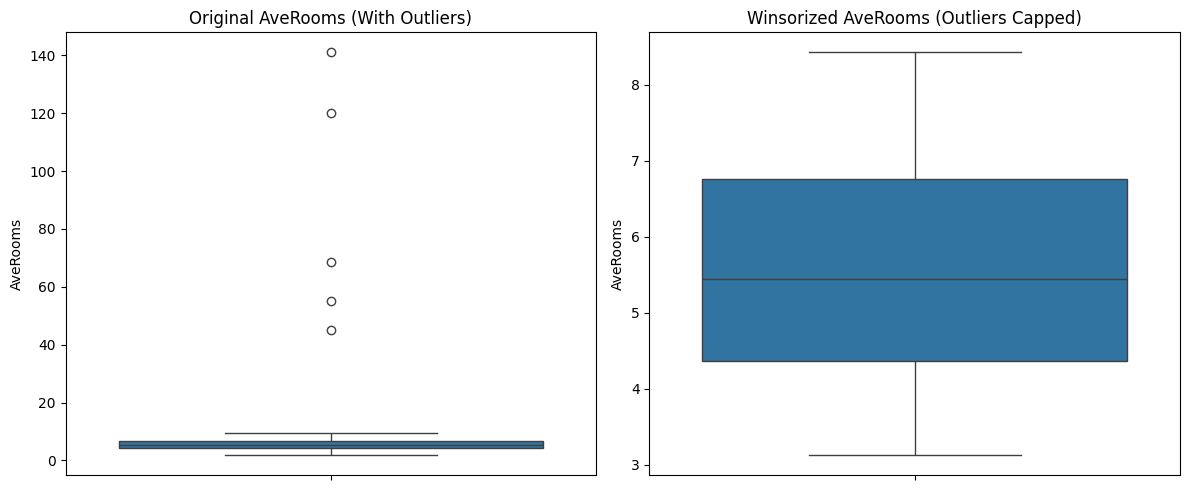

In [ ]:
#Winsorization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

!pip install feature_engine
from feature_engine.outliers import Winsorizer

 # Load data
df = pd.read_csv('/content/5_Winsorization_CaliforniaHousing.csv')

print(df)

print('_____'*35)

Q1 = df['AveRooms'].quantile(0.25)
print(Q1,'25% of Data')


Q3 = df['AveRooms'].quantile(0.75)
print(Q3,'75% of Data')

IQR = Q3 - Q1
print(IQR,'The IQR DAta')
lower_bound = Q1 - 1.5 * IQR



print(lower_bound,'By Substituting Q1')

upper_bound = Q3 + 1.5 * IQR

print(upper_bound,'By Substituting Q2')




# Replace values outside the 5th and 95th percentiles
lower_limit = df['AveRooms'].quantile(0.05)
upper_limit = df['AveRooms'].quantile(0.95)

print("*" * 45)

df['AveRooms_Winsorized'] = df['AveRooms'].clip(lower=lower_limit, upper=upper_limit)

print(f"Original Range: {df['AveRooms'].min()} to {df['AveRooms'].max()}")
print(f"Winsorized Range: {df['AveRooms_Winsorized'].min()} to {df['AveRooms_Winsorized'].max()}")

# Visualization
plt.figure(figsize=(12, 5))

# Plot Original
plt.subplot(1, 2, 1)
sns.boxplot(y=df['AveRooms'])
plt.title('Original AveRooms (With Outliers)')
plt.ylabel('AveRooms')

# Plot Winsorized
plt.subplot(1, 2, 2)
sns.boxplot(y=df['AveRooms_Winsorized'])
plt.title('Winsorized AveRooms (Outliers Capped)')
plt.ylabel('AveRooms')

plt.tight_layout()